# Experimenting with KDE and true pdf with Edge count simulations

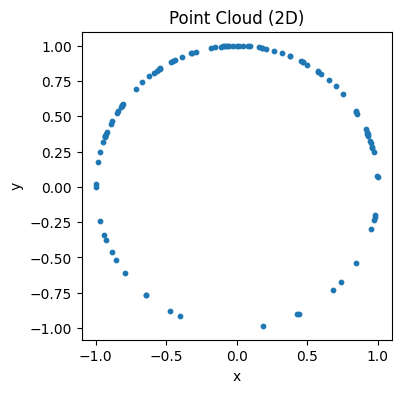

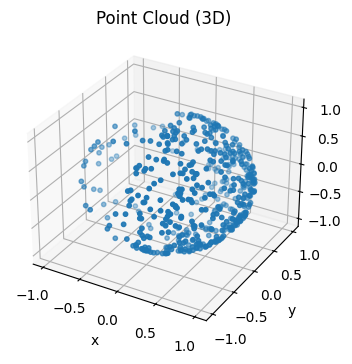

In [ ]:
import numpy as np
import ecc_vr as vr
import matplotlib.pyplot as plt

def hemisphere_biased_hypersphere(
    n_points,
    d,
    p=0.8,
    r=1.0,
    center=None,
    direction=None,
    seed=None,
    shuffle=True,
):
    # p = fraction of points in the hemisphere
    # {x : <x - center, direction> >= 0}

    if d < 2:
        raise ValueError("d must be at least 2")
    if not (0.0 <= p <= 1.0):
        raise ValueError("p must be between 0 and 1")

    rng = np.random.default_rng(seed)

    if direction is None:
        direction = np.zeros(d)
        direction[0] = 1.0

    direction = np.asarray(direction, dtype=float)
    if direction.shape != (d,):
        raise ValueError(f"direction must have shape ({d},)")

    direction_norm = np.linalg.norm(direction)
    if direction_norm == 0:
        raise ValueError("direction must be non-zero")
    direction = direction / direction_norm

    def sample_uniform_sphere(m):
        X = rng.normal(size=(m, d))
        norms = np.linalg.norm(X, axis=1, keepdims=True)

        while np.any(norms == 0):
            bad = norms[:, 0] == 0
            X[bad] = rng.normal(size=(bad.sum(), d))
            norms[bad] = np.linalg.norm(X[bad], axis=1, keepdims=True)

        return X / norms

    n_side = int(round(p * n_points))
    n_other = n_points - n_side

    # sample points for the chosen hemisphere
    X_side = sample_uniform_sphere(n_side)
    dots_side = X_side @ direction
    X_side[dots_side < 0] *= -1.0

    # sample points for the opposite hemisphere
    X_other = sample_uniform_sphere(n_other)
    dots_other = X_other @ direction
    X_other[dots_other > 0] *= -1.0

    X = np.vstack([X_side, X_other])

    if shuffle:
        rng.shuffle(X, axis=0)

    X *= r

    if center is not None:
        center = np.asarray(center, dtype=float)
        if center.shape != (d,):
            raise ValueError(f"center must have shape ({d},)")
        X += center

    return X

C = hemisphere_biased_hypersphere(
    n_points = 100,
    d = 2,
    p = 0.8,
    direction = [0,1],
    seed = None,
)
fig = plt.figure(figsize = (4,4))
ax = fig.add_subplot(111)
vr.plot_point_cloud_on_ax(ax, C, 2)
plt.show()

C2 = hemisphere_biased_hypersphere(
    n_points=500,
    d=3,
    p=0.8,          # 80% on one side
    direction=[1, 0, 0],      # which side
    seed=None,
)
fig2 = plt.figure(figsize = (4,4))
ax2 = fig2.add_subplot(111, projection = '3d')
vr.plot_point_cloud_on_ax(ax2, C2, 3)
plt.show()


In [ ]:
def count_edges(X: np.ndarray, t: float, D: np.ndarray | None = None) -> int:
    X = np.asarray(X, dtype = float)

    epsilon = 1/(t**(1/(X.shape[1]-1)))

    if D is None:
        D = vr.pairwise_dist(X)
    
    edge_count = int(np.count_nonzero(np.triu(D <= epsilon, k = 1)))
    return edge_count



Non-KDE adjusted edge count for circle above (t=1): 2103.
Non-KDE adjusted edge count for sphere above (t=1): 42737.

KDE adjusted edge count for circle above (t = 1, h = 0.15): 3009.
KDE adjusted edge count for sphere above (t = 1, h = 0.15): 61629.


# How to get pdf for n-dim hypershpere?

If points live in $\mathbb{R}^d$, then hypersphere surface is $S^{(d-1)}$, and density should be with respect to surface area on the sphere. For this hemisphere-biased model, the true pdf is piecewise constant $\frac{2p}{\text{area}}$ on the chosen hemisphere and $\frac{2(1-p)}{\text{area}}$ on the opposite hemisphere.

In [ ]:
import math

import math

def hypersphere_surface_area(d, r=1.0):
    if d < 2:
        raise ValueError("d must be at least 2")
    if r <= 0:
        raise ValueError("r must be positive")

    log_area = (
        math.log(2.0)
        + 0.5 * d * math.log(math.pi)
        + (d - 1) * math.log(r)
        - math.lgamma(d / 2.0)
    )
    return math.exp(log_area)


def hemisphere_biased_hypersphere_pdf(
    C,
    p = 0.8,
    r = 1.0,
    center = None,
    direction = None,
    tol = 1e-8,
):
    C = np.asarray(C, dtype=float)

    if C.ndim != 2:
        raise ValueError("C must have shape (n_points, d)")

    n_points, d = C.shape

    if not (0.0 <= p <= 1.0):
        raise ValueError("p must be between 0 and 1")

    if center is None:
        center = np.zeros(d)
    center = np.asarray(center, dtype=float)
    if center.shape != (d,):
        raise ValueError(f"center must have shape ({d},)")

    if direction is None:
        direction = np.zeros(d)
        direction[0] = 1.0
    direction = np.asarray(direction, dtype=float)
    if direction.shape != (d,):
        raise ValueError(f"direction must have shape ({d},)")

    direction_norm = np.linalg.norm(direction)
    if direction_norm == 0:
        raise ValueError("direction must be non-zero")
    direction = direction / direction_norm

    shifted = C - center
    radii = np.linalg.norm(shifted, axis=1)
    on_sphere = np.abs(radii - r) <= tol

    dots = shifted @ direction
    area = hypersphere_surface_area(d, r)

    pdf_vals = np.zeros(n_points, dtype=float)
    pdf_vals[on_sphere & (dots >= 0)] = 2.0 * p / area
    pdf_vals[on_sphere & (dots < 0)] = 2.0 * (1.0 - p) / area

    return pdf_vals

#Example Usage

C2 = hemisphere_biased_hypersphere(
    n_points=50,
    d=3,
    p=0.8,          # 80% on one side
    direction=[1, 0, 0],      # which side
    seed=None,
)

true_pdf = hemisphere_biased_hypersphere_pdf(
    C2,
    p=0.8,
    direction=[1, 0, 0],
)
print(true_pdf)

[0.12732395 0.12732395 0.12732395 0.12732395 0.12732395 0.12732395
 0.12732395 0.12732395 0.12732395 0.03183099 0.03183099 0.12732395
 0.12732395 0.12732395 0.03183099 0.12732395 0.12732395 0.12732395
 0.12732395 0.12732395 0.12732395 0.03183099 0.03183099 0.12732395
 0.12732395 0.12732395 0.12732395 0.03183099 0.12732395 0.12732395
 0.12732395 0.12732395 0.12732395 0.12732395 0.12732395 0.03183099
 0.12732395 0.12732395 0.03183099 0.12732395 0.12732395 0.03183099
 0.12732395 0.12732395 0.03183099 0.12732395 0.12732395 0.12732395
 0.12732395 0.12732395]


In [23]:
#implementing real pdf into distance matrix adjustment

def weighted_distance_matrix_pdf(
    X,
    p=0.8,
    r=1.0,
    center=None,
    direction=None,
    d_manifold=1,
    sym_rule="min",
    tol=1e-8,
):
  
    X = np.asarray(X, dtype=float)

    D = vr.pairwise_dist(X)

    f = hemisphere_biased_hypersphere_pdf(
        X,
        frac_on_side=p,
        r=r,
        center=center,
        direction=direction,
        tol=tol,
    )

    f = np.maximum(f, 1e-12)   # guard against zero density
    f = f / f.mean()
    s = f ** (1.0 / d_manifold)   # (n,)

    si = s[:, None]
    sj = s[None, :]

    rule = sym_rule.lower().strip()
    if rule == "min":
        scale = np.maximum(si, sj)
    elif rule == "max":
        scale = np.minimum(si, sj)
    elif rule in {"mean", "avg", "average"}:
        scale = (2.0 * si * sj) / (si + sj)
    else:
        raise ValueError("sym_rule must be 'min', 'max', or 'mean'")

    D_w = D * scale
    np.fill_diagonal(D_w, 0.0)
    return D_w, f

In [52]:
print(f"Non-KDE adjusted edge count for circle above (t=1): {count_edges(C, t=1)}.")
print(f"Non-KDE adjusted edge count for sphere above (t=1): {count_edges(C2, t=1)}.\n")

Dw_circleK, _ = vr.weighted_distance_matrix_kde(C, h=0.15, d_manifold=1, sym_rule="mean")
Dw_sphereK, _ = vr.weighted_distance_matrix_kde(C2, h=0.15, d_manifold =1, sym_rule="mean")

Dw_circleK2, _ = vr.weighted_distance_matrix_kde(C, h=0.17, d_manifold=1, sym_rule="mean")
Dw_sphereK2, _ = vr.weighted_distance_matrix_kde(C2, h=0.12, d_manifold =1, sym_rule="mean")

print(f"KDE adjusted edge count for circle above (t = 1, h = 0.15): {count_edges(C, t=1,D=Dw_circleK)}.")
print(f"KDE adjusted edge count for sphere above (t = 1, h = 0.15): {count_edges(C2, t=1,D=Dw_sphereK)}.\n")
print(f"KDE adjusted edge count for circle above (t = 1, h = 0.17): {count_edges(C, t=1,D=Dw_circleK2)}.")
print(f"KDE adjusted edge count for sphere above (t = 1, h = 0.12): {count_edges(C2, t=1,D=Dw_sphereK2)}.\n")

Dw_circle, _ = weighted_distance_matrix_pdf(C, d_manifold=1, p = 0.8, sym_rule="mean")
Dw_sphere, _ = weighted_distance_matrix_pdf(C2, d_manifold=2, p=0.8,sym_rule="mean" )

print(f"PDF adjusted edge count for circle above (t = 1): {count_edges(C, t=1,D=Dw_circle)}.")
print(f"PDF adjusted edge count for sphere above (t = 1): {count_edges(C2, t=1,D=Dw_sphere)}.")


Non-KDE adjusted edge count for circle above (t=1): 2103.
Non-KDE adjusted edge count for sphere above (t=1): 357.

KDE adjusted edge count for circle above (t = 1, h = 0.15): 3009.
KDE adjusted edge count for sphere above (t = 1, h = 0.15): 429.

KDE adjusted edge count for circle above (t = 1, h = 0.17): 2942.
KDE adjusted edge count for sphere above (t = 1, h = 0.12): 400.

PDF adjusted edge count for circle above (t = 1): 2941.
PDF adjusted edge count for sphere above (t = 1): 397.
